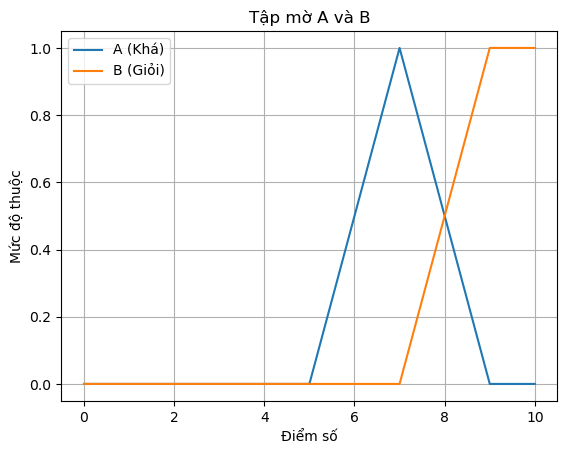

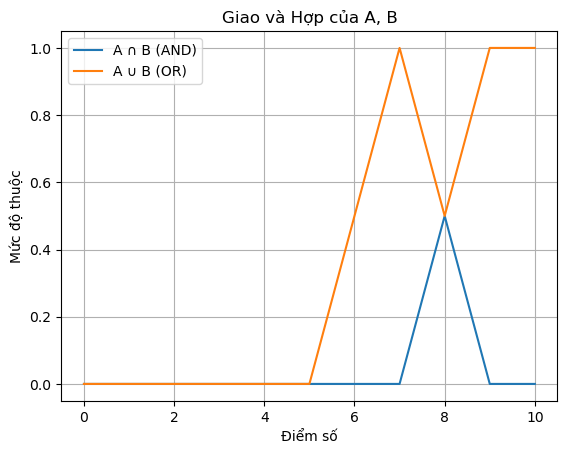

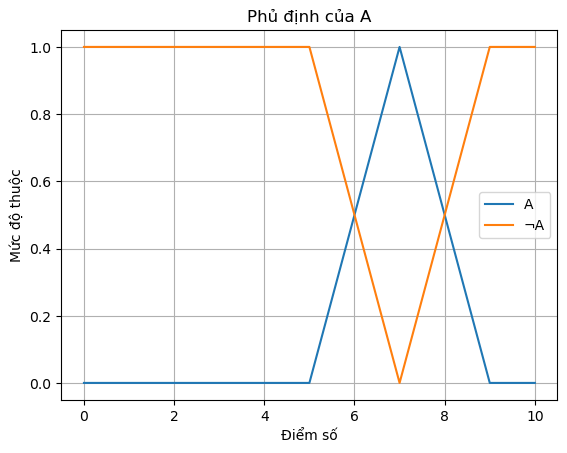

Sai số tối đa của De Morgan 1: 0.0
Sai số tối đa của De Morgan 2: 0.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Không gian nền X: điểm số từ 0 đến 10
x = np.linspace(0, 10, 1001)

# 2. Định nghĩa hàm thuộc cho A: "Khá"
def mu_A(x):
    x = np.asarray(x)
    mu = np.zeros_like(x, dtype=float)
    # đoạn 5-7: tăng tuyến tính từ 0 -> 1
    mask1 = (x >= 5) & (x < 7)
    mu[mask1] = (x[mask1] - 5) / 2.0
    # đoạn 7-9: giảm tuyến tính từ 1 -> 0
    mask2 = (x >= 7) & (x <= 9)
    mu[mask2] = (9 - x[mask2]) / 2.0
    return mu

# 3. Định nghĩa hàm thuộc cho B: "Giỏi"
def mu_B(x):
    x = np.asarray(x)
    mu = np.zeros_like(x, dtype=float)
    # đoạn 7-9: tăng tuyến tính 0 -> 1
    mask1 = (x >= 7) & (x < 9)
    mu[mask1] = (x[mask1] - 7) / 2.0
    # từ 9 trở lên: 1
    mask2 = (x >= 9)
    mu[mask2] = 1.0
    return mu

A = mu_A(x)
B = mu_B(x)

# 4. Phép toán trên tập mờ
A_and_B = np.minimum(A, B)   # giao
A_or_B  = np.maximum(A, B)   # hợp
not_A   = 1 - A              # phủ định A
not_B   = 1 - B              # phủ định B

# 5. Vẽ hàm thuộc ban đầu A, B
plt.figure()
plt.plot(x, A, label="A (Khá)")
plt.plot(x, B, label="B (Giỏi)")
plt.title("Tập mờ A và B")
plt.xlabel("Điểm số")
plt.ylabel("Mức độ thuộc")
plt.legend()
plt.grid(True)
plt.show()

# 6. Vẽ giao A∩B và hợp A∪B
plt.figure()
plt.plot(x, A_and_B, label="A ∩ B (AND)")
plt.plot(x, A_or_B, label="A ∪ B (OR)")
plt.title("Giao và Hợp của A, B")
plt.xlabel("Điểm số")
plt.ylabel("Mức độ thuộc")
plt.legend()
plt.grid(True)
plt.show()

# 7. Vẽ phủ định của A
plt.figure()
plt.plot(x, A, label="A")
plt.plot(x, not_A, label="¬A")
plt.title("Phủ định của A")
plt.xlabel("Điểm số")
plt.ylabel("Mức độ thuộc")
plt.legend()
plt.grid(True)
plt.show()

# 8. Kiểm tra luật De Morgan: ¬(A ∪ B) = ¬A ∩ ¬B
left  = 1 - A_or_B
right = np.minimum(not_A, not_B)

print("Sai số tối đa của De Morgan 1:",
      np.max(np.abs(left - right)))

# 9. Kiểm tra luật De Morgan thứ 2: ¬(A ∩ B) = ¬A ∪ ¬B
left2  = 1 - A_and_B
right2 = np.maximum(not_A, not_B)

print("Sai số tối đa của De Morgan 2:",
      np.max(np.abs(left2 - right2)))